# Chicago Crimes EDA 

## 0. Setup & Environment


In [1]:
import os, glob, warnings, math
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

warnings.filterwarnings('ignore')

# Palet warna
BRAND_INDIGO  = '#3D2B9E'
BRAND_VIOLET  = '#7B3FE4'
BRAND_MAGENTA = '#CE1C8E'
BRAND_PINK    = '#EC6DB4'
BRAND_LIGHT   = '#F7B4DA'
BRAND_COLORS  = [BRAND_MAGENTA, BRAND_INDIGO, BRAND_VIOLET, BRAND_PINK, BRAND_LIGHT]
ACCENT  = BRAND_MAGENTA
ACCENT2 = BRAND_INDIGO

# Colormap kontinu
BRAND_CMAP = LinearSegmentedColormap.from_list(
    'brand', ['#241663', BRAND_INDIGO, BRAND_VIOLET, BRAND_MAGENTA, BRAND_PINK, BRAND_LIGHT])
try:
    mpl.colormaps.register(BRAND_CMAP)
    mpl.colormaps.register(BRAND_CMAP.reversed())
except (ValueError, AttributeError):
    pass

def brand_palette(n):
    n = max(int(n), 1)
    return [BRAND_CMAP(x) for x in np.linspace(0.12, 0.92, n)]

PALETTE = 'brand'
sns.set_palette(BRAND_COLORS)
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=BRAND_COLORS)
plt.rcParams['image.cmap']  = 'brand'
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25


### 0.1 Konfigurasi

DATA_PATH diarahkan langsung ke dataset di input Kaggle. SAMPLE_FRAC = 1.0 memakai seluruh data; turunkan untuk uji cepat.


In [2]:
SAMPLE_FRAC = 1.0        
RANDOM_STATE = 42

DATA_DIR  = '/kaggle/input/datasets/fransiskaadin/chicago-crimes'
DATA_PATH = '/kaggle/input/datasets/fransiskaadin/chicago-crimes/Crimes_-_2001_to_Present_20260420.csv'

# Fallback lokal 
if not os.path.exists(DATA_PATH) and os.path.exists('crimes_chicago.csv'):
    DATA_PATH = 'crimes_chicago.csv'

print('DATA_PATH:', DATA_PATH)
assert os.path.exists(DATA_PATH), f'File tidak ditemukan: {DATA_PATH}. Pastikan dataset sudah di-Add Input.'
print(f'Ukuran file: {os.path.getsize(DATA_PATH)/1e6:.1f} MB')


DATA_PATH: /kaggle/input/datasets/fransiskaadin/chicago-crimes/Crimes_-_2001_to_Present_20260420.csv
Ukuran file: 2372.1 MB


## 1. Data Loading


In [3]:
# dtypes hemat memori: kolom kategorikal/boolean dibaca sebagai str/float dulu,
# lalu dikonversi setelah load agar konsisten dan hemat RAM.
DTYPES = {
    'ID': 'int64',
    'Case Number': 'str',
    'IUCR': 'str',
    'Primary Type': 'str',
    'Description': 'str',
    'Location Description': 'str',
    'Arrest': 'str',
    'Domestic': 'str',
    'FBI Code': 'str',
    'Beat': 'float32',
    'District': 'float32',
    'Ward': 'float32',
    'Community Area': 'float32',
    'X Coordinate': 'float32',
    'Y Coordinate': 'float32',
    'Year': 'float32',
    'Latitude': 'float32',
    'Longitude': 'float32',
}
# Buang kolom 'Location' (duplikat Latitude/Longitude, boros memori) via usecols
USECOLS = list(DTYPES.keys()) + ['Date', 'Block', 'Updated On']

%time df = pd.read_csv(DATA_PATH, dtype=DTYPES, usecols=USECOLS)
print('Shape mentah:', df.shape)

# Konversi tipe setelah load
df['Arrest']   = df['Arrest'].astype('str').str.strip().str.lower().eq('true')
df['Domestic'] = df['Domestic'].astype('str').str.strip().str.lower().eq('true')
for col in ['IUCR', 'Primary Type', 'Description', 'Location Description', 'FBI Code']:
    df[col] = df[col].astype('category')

if 0 < SAMPLE_FRAC < 1.0:
    df = df.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE).reset_index(drop=True)
    print('Shape setelah sampling:', df.shape)


CPU times: user 36.6 s, sys: 6.18 s, total: 42.8 s
Wall time: 52.6 s
Shape mentah: (8534663, 21)


In [4]:
# Parse tanggal (format Chicago: MM/DD/YYYY HH:MM:SS AM/PM)
%time df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
df['Updated On'] = pd.to_datetime(df['Updated On'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
print('Rentang tanggal:', df['Date'].min(), '->', df['Date'].max())
print('Tanggal gagal diparse (NaT):', int(df['Date'].isna().sum()))


CPU times: user 20.5 s, sys: 365 ms, total: 20.9 s
Wall time: 20.8 s
Rentang tanggal: 2001-01-01 00:00:00 -> 2026-04-11 00:00:00
Tanggal gagal diparse (NaT): 0


In [5]:
df.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude
0,14165870,JK216131,2026-04-11,051XX S ABERDEEN ST,0820,THEFT,$500 AND UNDER,STREET,False,False,...,9.0,20.0,61.0,06,1169852.0,1870819.0,2026.0,2026-04-18 15:41:37,41.801025,-87.652618
1,14170655,JK222155,2026-04-11,034XX N OSAGE AVE,1154,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT $300 AND UNDER,RESIDENCE,False,False,...,16.0,38.0,17.0,11,NaN,NaN,2026.0,2026-04-18 15:41:37,NaN,NaN
2,14164088,JK214233,2026-04-11,019XX W MAYPOLE AVE,0460,BATTERY,SIMPLE,STREET,False,False,...,12.0,27.0,28.0,08B,1163456.0,1901042.0,2026.0,2026-04-18 15:41:37,41.884098,-87.675232
3,14163678,JK213573,2026-04-11,027XX W BERWYN AVE,1220,DECEPTIVE PRACTICE,THEFT OF LOST / MISLAID PROPERTY,APARTMENT,True,False,...,20.0,40.0,4.0,11,1157124.0,1935089.0,2026.0,2026-04-18 15:41:37,41.977654,-87.697556
4,14164937,JK215217,2026-04-11,008XX W IRVING PARK RD,0710,THEFT,THEFT FROM MOTOR VEHICLE,GAS STATION,False,False,...,19.0,46.0,6.0,06,1169809.0,1926762.0,2026.0,2026-04-18 15:41:37,41.954536,-87.651146


In [6]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8534663 entries, 0 to 8534662
Data columns (total 21 columns):
 #   Column                Dtype         
---  ------                -----         
 0   ID                    int64         
 1   Case Number           object        
 2   Date                  datetime64[ns]
 3   Block                 object        
 4   IUCR                  category      
 5   Primary Type          category      
 6   Description           category      
 7   Location Description  category      
 8   Arrest                bool          
 9   Domestic              bool          
 10  Beat                  float32       
 11  District              float32       
 12  Ward                  float32       
 13  Community Area        float32       
 14  FBI Code              category      
 15  X Coordinate          float32       
 16  Y Coordinate          float32       
 17  Year                  float32       
 18  Updated On            datetime64[ns]
 19  

## 2. Data Quality Assessment

Memeriksa kelengkapan dan kebersihan data sebelum feature engineering


Kolom dengan missing values:


,missing,missing_%
Ward,614815,7.20
Community Area,613726,7.19
X Coordinate,96386,1.13
Y Coordinate,96386,1.13
Longitude,96386,1.13
Latitude,96386,1.13
Location Description,15901,0.19
District,47,0.00


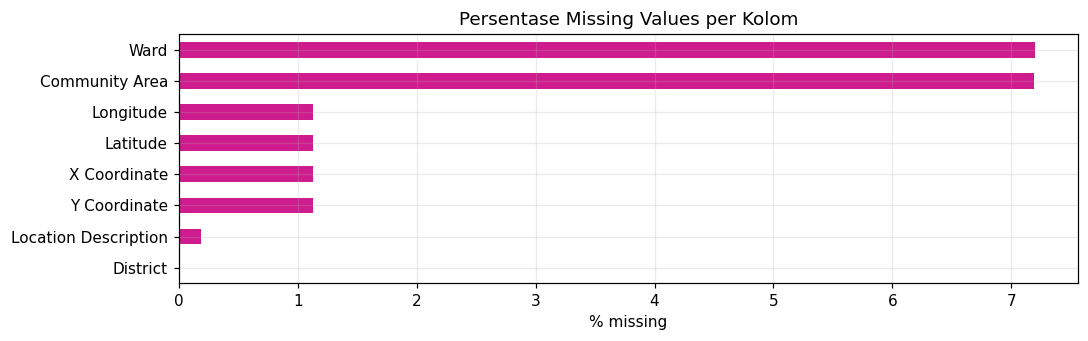

In [7]:
# Missing values
miss = df.isna().sum().sort_values(ascending=False)
miss_pct = (miss / len(df) * 100).round(2)
quality = pd.DataFrame({'missing': miss, 'missing_%': miss_pct})
quality = quality[quality['missing'] > 0]
print('Kolom dengan missing values:')
display(quality)

if len(quality):
    plt.figure(figsize=(10, max(3, 0.4*len(quality))))
    quality['missing_%'].sort_values().plot(kind='barh', color=ACCENT)
    plt.title('Persentase Missing Values per Kolom')
    plt.xlabel('% missing'); plt.tight_layout(); plt.show()


**Interpretasi - kualitas data.** Missing terkonsentrasi pada `Ward` (7,20%) dan `Community Area` (7,19%) yang sebagian besar berasal dari era awal (2001-2002) sehingga bersifat *natural*, bukan error entri. Koordinat hilang hanya 1,13% dan cenderung menempel pada tipe sensitif (kekerasan seksual, kejahatan terhadap anak) - indikasi *redaksi privasi*, bukan cacat acak. Keputusan: tandai (`coord_missing`) namun jangan imputasi, agar tidak memalsukan lokasi.


In [8]:
# Duplikasi
n_dup_id = int(df['ID'].duplicated().sum())
n_dup_case = int(df['Case Number'].duplicated().sum())
n_dup_row = int(df.duplicated().sum())
print(f'Duplikat ID           : {n_dup_id:,}')
print(f'Duplikat Case Number  : {n_dup_case:,}')
print(f'Duplikat baris penuh  : {n_dup_row:,}')


Duplikat ID           : 0
Duplikat Case Number  : 613
Duplikat baris penuh  : 0


In [9]:
# Kardinalitas kolom kategorikal (dasar keputusan encoding)
cat_cols = ['Primary Type','Description','Location Description','IUCR','FBI Code',
            'District','Ward','Community Area','Beat']
card = {c: df[c].nunique(dropna=True) for c in cat_cols if c in df.columns}
card = pd.Series(card).sort_values(ascending=False)
print('Jumlah nilai unik (cardinality):')
display(card.to_frame('n_unique'))


Jumlah nilai unik (cardinality):


,n_unique
Description,569
IUCR,418
Beat,305
Location Description,218
Community Area,78
Ward,50
Primary Type,34
FBI Code,26
District,24


In [10]:
# Validitas koordinat: Chicago kira-kira lat 41.6-42.1, lon -87.95 - -87.5
lat, lon = df['Latitude'], df['Longitude']
valid_geo = lat.notna() & lon.notna()
outlier_geo = valid_geo & (~lat.between(41.6, 42.1) | ~lon.between(-87.95, -87.5))
print(f'Baris punya koordinat : {int(valid_geo.sum()):,} ({valid_geo.mean()*100:.1f}%)')
print(f'Koordinat di luar Chicago (outlier): {int(outlier_geo.sum()):,}')
print('\nStatistik koordinat:')
display(df[['Latitude','Longitude']].describe())


Baris punya koordinat : 8,438,277 (98.9%)
Koordinat di luar Chicago (outlier): 149

Statistik koordinat:


,Latitude,Longitude
count,8.438277e+06,8.438277e+06
mean,4.184258e+01,-8.767124e+01
std,1.206577e+00,5.638730e+00
min,3.661945e+01,-9.168657e+01
25%,4.176900e+01,-8.771324e+01
50%,4.185669e+01,-8.766547e+01
75%,4.190711e+01,-8.762806e+01
max,4.202291e+01,-8.752453e+01


**Interpretasi - validitas koordinat.** Mayoritas baris (98,9%) memiliki koordinat valid di dalam bounding box Chicago; hanya 149 titik jatuh di luar batil wajar dan diperlakukan sebagai outlier. Kualitas geospasial yang tinggi ini menjadi syarat penting agar agregasi berbasis grid pada tahap feature engineering dapat diandalkan.


## 3. Gambaran Umum Kejahatan

Volume dan komposisi kejahatan: total insiden, rentang waktu, dan jenis kejahatan paling dominan.


In [11]:
print(f'Total insiden : {len(df):,}')
print(f'Rentang waktu : {df["Date"].min().date()} s/d {df["Date"].max().date()}')
print(f'Tipe kejahatan (Primary Type): {df["Primary Type"].nunique()}')
print(f'Community Area : {df["Community Area"].nunique()}')
print(f'Arrest rate   : {df["Arrest"].mean()*100:.1f}%')
print(f'Domestic rate : {df["Domestic"].mean()*100:.1f}%')


Total insiden : 8,534,663
Rentang waktu : 2001-01-01 s/d 2026-04-11
Tipe kejahatan (Primary Type): 34
Community Area : 78
Arrest rate   : 25.1%
Domestic rate : 17.3%


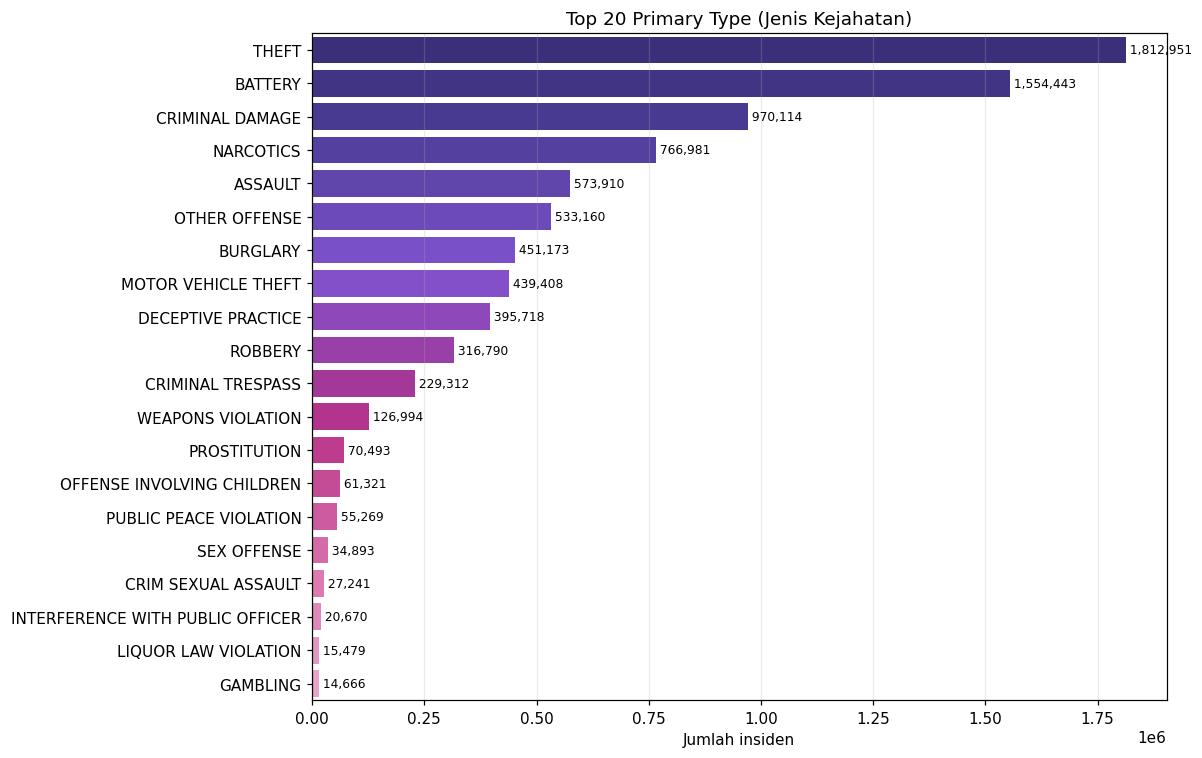

In [12]:
# Top 20 Primary Type
top_pt = df['Primary Type'].value_counts().head(20)
plt.figure(figsize=(11,7))
sns.barplot(x=top_pt.values, y=top_pt.index.astype(str),
            hue=top_pt.index.astype(str), palette=brand_palette(len(top_pt)), legend=False)
plt.title('Top 20 Primary Type (Jenis Kejahatan)')
plt.xlabel('Jumlah insiden'); plt.ylabel('')
for i, v in enumerate(top_pt.values):
    plt.text(v, i, f' {v:,}', va='center', fontsize=8)
plt.tight_layout(); plt.show()


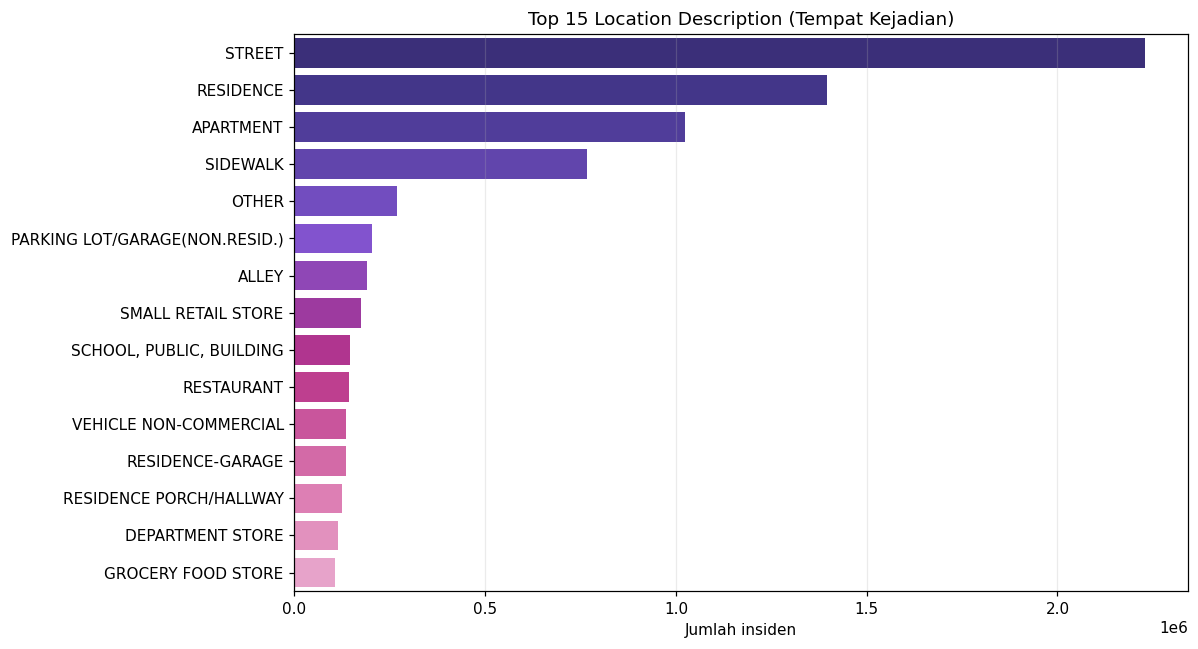

In [13]:
# Top 15 Location Description
top_loc = df['Location Description'].value_counts().head(15)
plt.figure(figsize=(11,6))
sns.barplot(x=top_loc.values, y=top_loc.index.astype(str),
            hue=top_loc.index.astype(str), palette=brand_palette(len(top_loc)), legend=False)
plt.title('Top 15 Location Description (Tempat Kejadian)')
plt.xlabel('Jumlah insiden'); plt.ylabel('')
plt.tight_layout(); plt.show()


**Interpretasi - komposisi kejahatan.** Distribusi tipe sangat *long-tail*: `THEFT` (~1,81 jt) dan `BATTERY` (~1,55 jt) mendominasi, diikuti `CRIMINAL DAMAGE`, `NARCOTICS`, dan `ASSAULT`. Secara lokasi, insiden paling banyak terjadi di ruang publik (STREET) dan hunian (RESIDENCE/APARTMENT). Dominasi kejahatan volume-tinggi bernilai-bahaya-rendah inilah alasan severity tidak boleh disamaratakan - perlu pembobotan per tipe + deskripsi di tahap pseudo-labeling.


## 4. Temporal EDA

Mengekstrak komponen waktu dan membuktikan sifat siklikalnya. Menjadi justifikasi cyclical (sin/cos) encoding pada Feature Engineering.


In [14]:
# Ekstraksi komponen waktu
d = df.dropna(subset=['Date']).copy()
d['year']  = d['Date'].dt.year
d['month'] = d['Date'].dt.month
d['day']   = d['Date'].dt.day
d['dow']   = d['Date'].dt.dayofweek       # 0=Senin
d['hour']  = d['Date'].dt.hour
d['doy']   = d['Date'].dt.dayofyear
d['date_only'] = d['Date'].dt.normalize()
print('Fitur waktu diekstrak. Contoh:')
display(d[['Date','year','month','dow','hour']].head())


Fitur waktu diekstrak. Contoh:


,Date,year,month,dow,hour
0,2026-04-11,2026,4,5,0
1,2026-04-11,2026,4,5,0
2,2026-04-11,2026,4,5,0
3,2026-04-11,2026,4,5,0
4,2026-04-11,2026,4,5,0


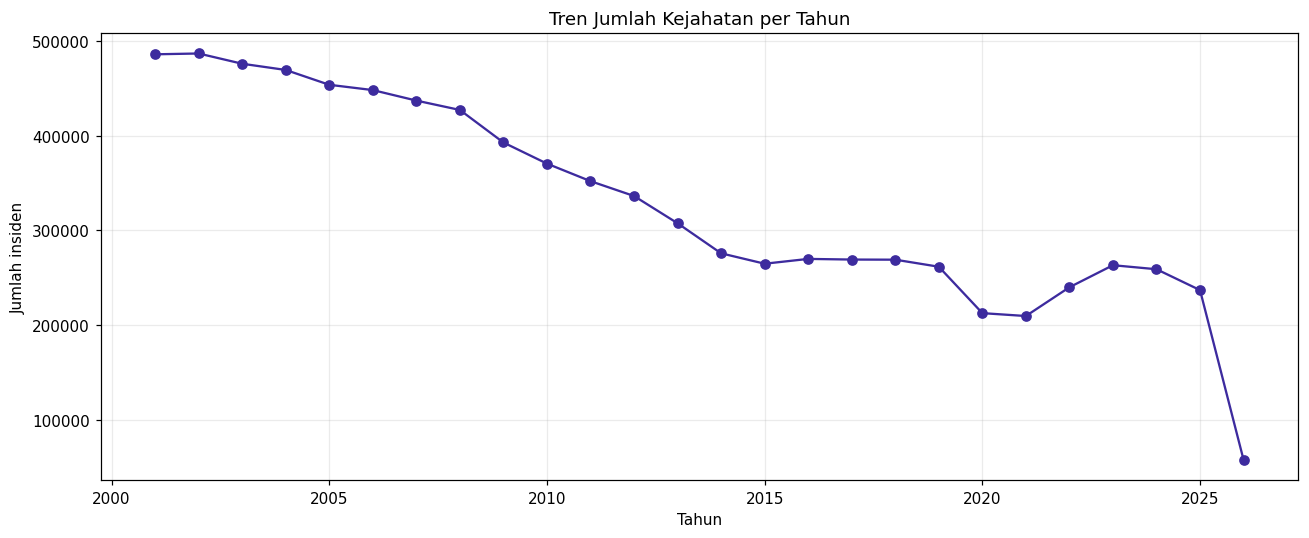

Catatan: tahun berjalan (terakhir) biasanya belum lengkap.


In [15]:
# Tren tahunan
yearly = d.groupby('year').size()
plt.figure(figsize=(12,5))
yearly.plot(marker='o', color=ACCENT2)
plt.title('Tren Jumlah Kejahatan per Tahun')
plt.ylabel('Jumlah insiden'); plt.xlabel('Tahun')
plt.tight_layout(); plt.show()
print('Catatan: tahun berjalan (terakhir) biasanya belum lengkap.')


**Interpretasi - tren jangka panjang.** Volume kejahatan menurun konsisten dari ~486 rb (2001) hingga titik terendah sekitar 2020-2021 (~210 rb), lalu sedikit naik pada 2022-2024. Tahun berjalan (2026) tampak rendah karena datanya belum lengkap. Implikasi desain: data lama masih informatif untuk pola spasial, tetapi relevansinya terhadap tingkat risiko *saat ini* menurun - memperkuat kebutuhan *temporal decay*.


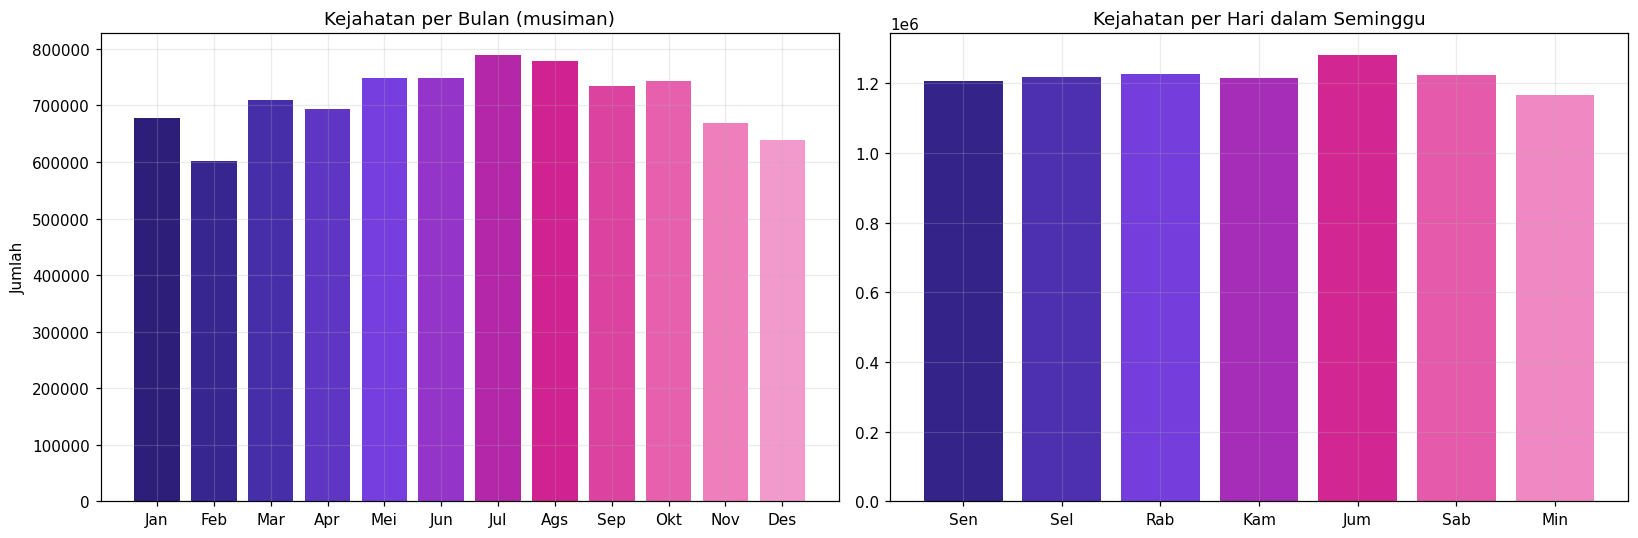

In [16]:
# Seasonality bulanan & harian
fig, ax = plt.subplots(1, 2, figsize=(15,5))
month_names = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Ags','Sep','Okt','Nov','Des']
by_month = d.groupby('month').size()
ax[0].bar(range(1,13), [by_month.get(m,0) for m in range(1,13)], color=sns.color_palette(PALETTE,12))
ax[0].set_xticks(range(1,13)); ax[0].set_xticklabels(month_names)
ax[0].set_title('Kejahatan per Bulan (musiman)'); ax[0].set_ylabel('Jumlah')

dow_names = ['Sen','Sel','Rab','Kam','Jum','Sab','Min']
by_dow = d.groupby('dow').size()
ax[1].bar(range(7), [by_dow.get(i,0) for i in range(7)], color=sns.color_palette(PALETTE,7))
ax[1].set_xticks(range(7)); ax[1].set_xticklabels(dow_names)
ax[1].set_title('Kejahatan per Hari dalam Seminggu')
plt.tight_layout(); plt.show()


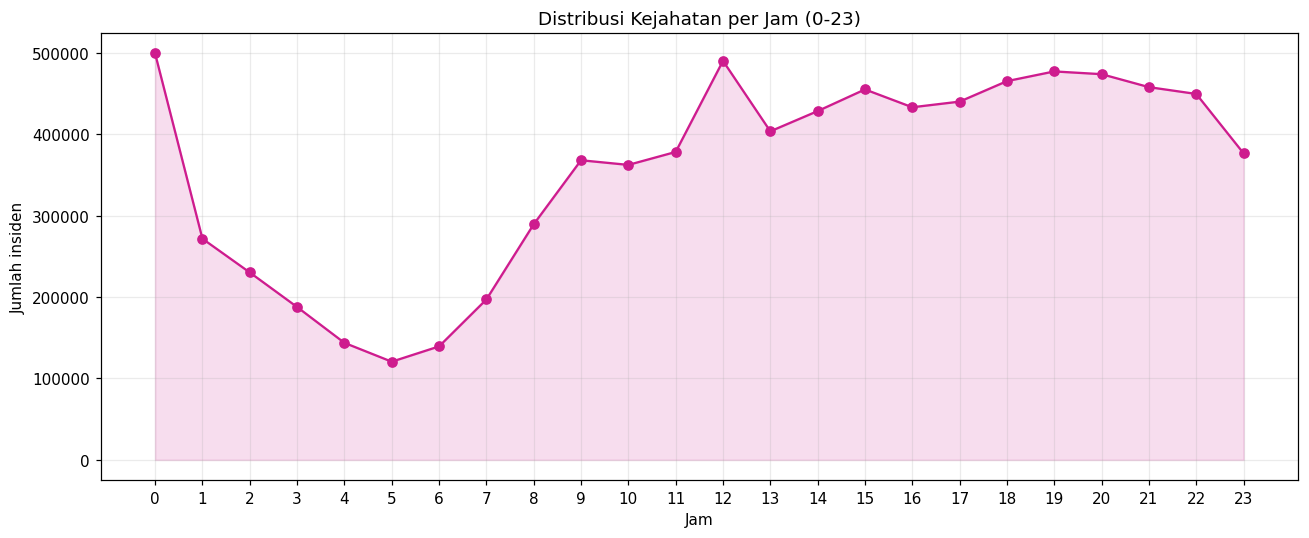

Jam 23 dan jam 0 nyatanya berdekatan, namun sebagai angka linear jaraknya jauh (23 vs 0).


In [17]:
# Distribusi per jam - kunci untuk cyclical encoding
by_hour = d.groupby('hour').size().sort_index()
plt.figure(figsize=(12,5))
plt.plot(by_hour.index, by_hour.values, marker='o', color=ACCENT)
plt.fill_between(by_hour.index, by_hour.values, alpha=0.15, color=ACCENT)
plt.title('Distribusi Kejahatan per Jam (0-23)')
plt.xlabel('Jam'); plt.ylabel('Jumlah insiden'); plt.xticks(range(0,24))
plt.tight_layout(); plt.show()
print('Jam 23 dan jam 0 nyatanya berdekatan, namun sebagai angka linear jaraknya jauh (23 vs 0).')


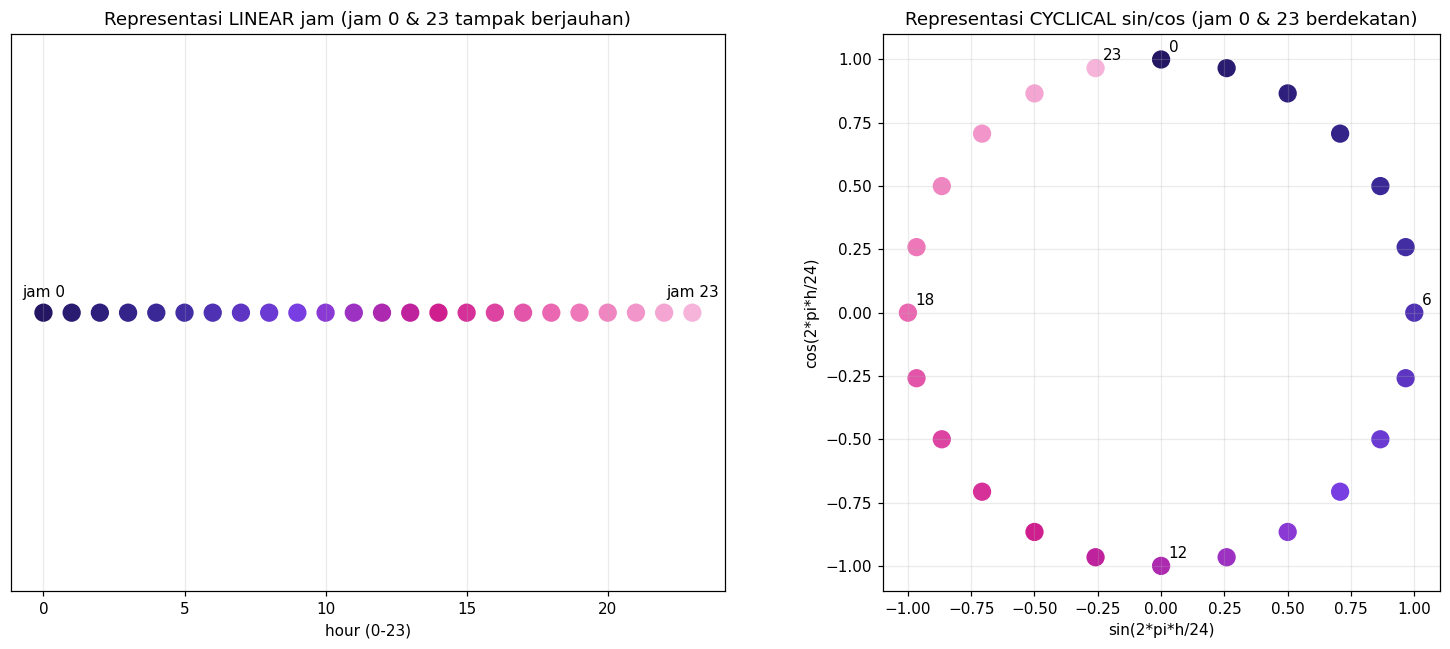

Justifikasi FE: gunakan cyclical (sin/cos) encoding untuk hour, dow, month, day-of-year.


In [18]:
# Bukti sifat siklikal: representasi linear vs sin/cos untuk jam
hours = np.arange(24)
hour_sin = np.sin(2*np.pi*hours/24)
hour_cos = np.cos(2*np.pi*hours/24)

fig, ax = plt.subplots(1, 2, figsize=(14,6))
ax[0].scatter(hours, np.zeros_like(hours), c=hours, cmap=PALETTE, s=120)
for h in [0,23]:
    ax[0].annotate(f'jam {h}', (h,0), textcoords='offset points', xytext=(0,10), ha='center')
ax[0].set_title('Representasi LINEAR jam (jam 0 & 23 tampak berjauhan)')
ax[0].set_yticks([]); ax[0].set_xlabel('hour (0-23)')

ax[1].scatter(hour_sin, hour_cos, c=hours, cmap=PALETTE, s=120)
for h in [0,6,12,18,23]:
    ax[1].annotate(f'{h}', (hour_sin[h], hour_cos[h]), textcoords='offset points', xytext=(5,5))
ax[1].set_title('Representasi CYCLICAL sin/cos (jam 0 & 23 berdekatan)')
ax[1].set_xlabel('sin(2*pi*h/24)'); ax[1].set_ylabel('cos(2*pi*h/24)'); ax[1].set_aspect('equal')
plt.tight_layout(); plt.show()
print('Justifikasi FE: gunakan cyclical (sin/cos) encoding untuk hour, dow, month, day-of-year.')


**Interpretasi - bukti sifat siklikal.** Jam 23 dan jam 00 sesungguhnya berdampingan, tetapi sebagai angka linear jaraknya maksimal (23 vs 0). Plot linear vs `sin/cos` memperlihatkan bahwa hanya encoding siklikal yang menjaga kedekatan ujung-ujung siklus. Justifikasi langsung: `hour`, `dow`, dan `month` akan direpresentasikan dengan cyclical (sin/cos) encoding pada notebook feature engineering.


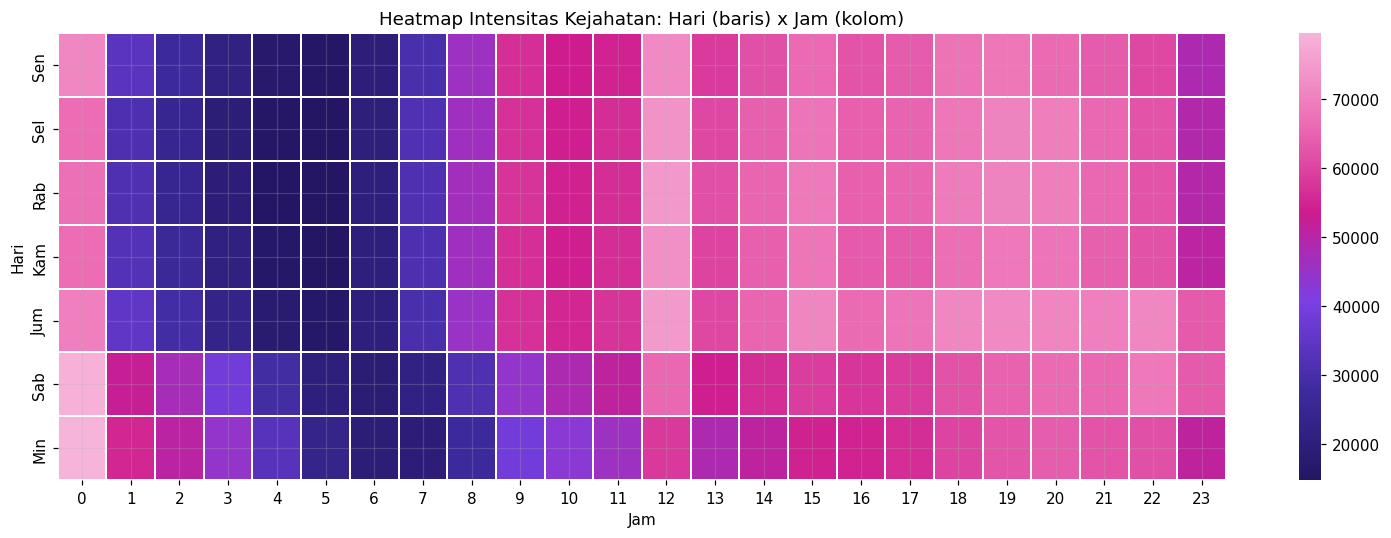

In [19]:
# Heatmap Jam x Hari
pivot = d.pivot_table(index='dow', columns='hour', values='ID', aggfunc='count')
pivot = pivot.reindex(index=range(7), columns=range(24)).fillna(0)
pivot.index = dow_names
plt.figure(figsize=(14,5))
sns.heatmap(pivot, cmap=PALETTE, linewidths=.3)
plt.title('Heatmap Intensitas Kejahatan: Hari (baris) x Jam (kolom)')
plt.xlabel('Jam'); plt.ylabel('Hari')
plt.tight_layout(); plt.show()


**Interpretasi - pola jam x hari.** Heatmap menunjukkan konsentrasi insiden pada sore hingga malam hari dan menurun tajam pada dini hari (~03:00-05:00), dengan pola akhir pekan yang sedikit berbeda dari hari kerja. Ini menegaskan bahwa jam dan hari membawa sinyal risiko nyata sehingga layak dipertahankan sebagai fitur (mis. `share_night`, `share_weekend`).


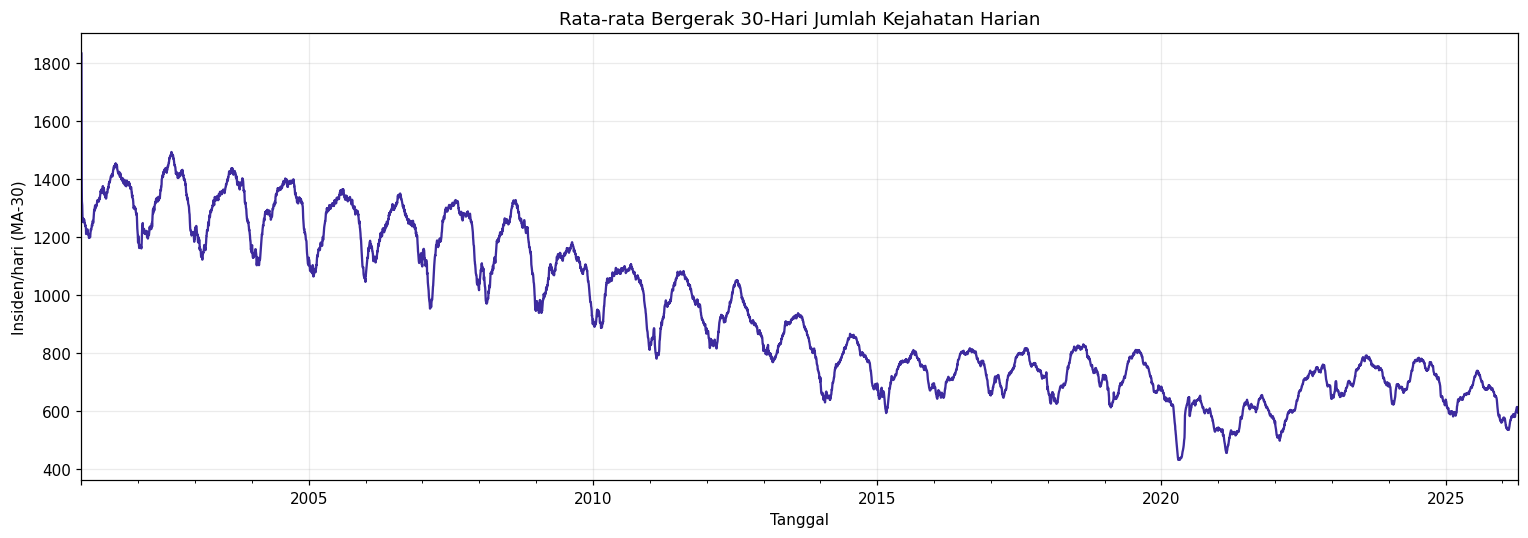

In [20]:
# Tren harian jangka panjang (rolling 30 hari)
daily = d.groupby('date_only').size().sort_index()
plt.figure(figsize=(14,5))
daily.rolling(30, min_periods=1).mean().plot(color=ACCENT2)
plt.title('Rata-rata Bergerak 30-Hari Jumlah Kejahatan Harian')
plt.ylabel('Insiden/hari (MA-30)'); plt.xlabel('Tanggal')
plt.tight_layout(); plt.show()


**Interpretasi - dinamika harian.** Kurva rolling 30-hari memperlihatkan dua lapis pola sekaligus: tren penurunan multi-tahun dan gelombang musiman tahunan. Keduanya memotivasi fitur *lag* dan *rolling mean* agar model menangkap momentum dan musim, bukan sekadar cuplikan satu bulan.


## 5. Spatial EDA

Memetakan sebaran dan hotspot koordinat. Menjadi justifikasi grid aggregation pada Feature Engineering spasial.


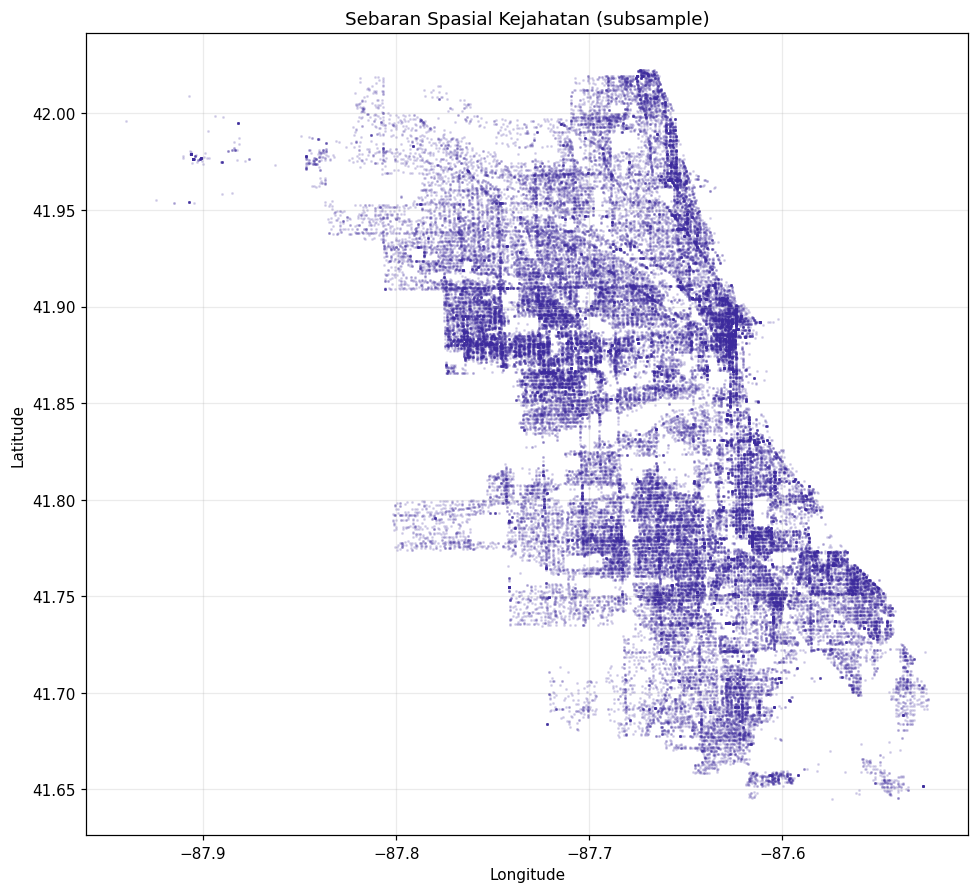

In [21]:
# Sebaran spasial (scatter) 
geo = d.dropna(subset=['Latitude','Longitude'])
geo = geo[geo['Latitude'].between(41.6,42.1) & geo['Longitude'].between(-87.95,-87.5)]
plot_geo = geo.sample(n=min(80000, len(geo)), random_state=RANDOM_STATE)
plt.figure(figsize=(9,10))
plt.scatter(plot_geo['Longitude'], plot_geo['Latitude'], s=1, alpha=0.15, color=ACCENT2)
plt.title('Sebaran Spasial Kejahatan (subsample)')
plt.xlabel('Longitude'); plt.ylabel('Latitude'); plt.gca().set_aspect('equal')
plt.tight_layout(); plt.show()


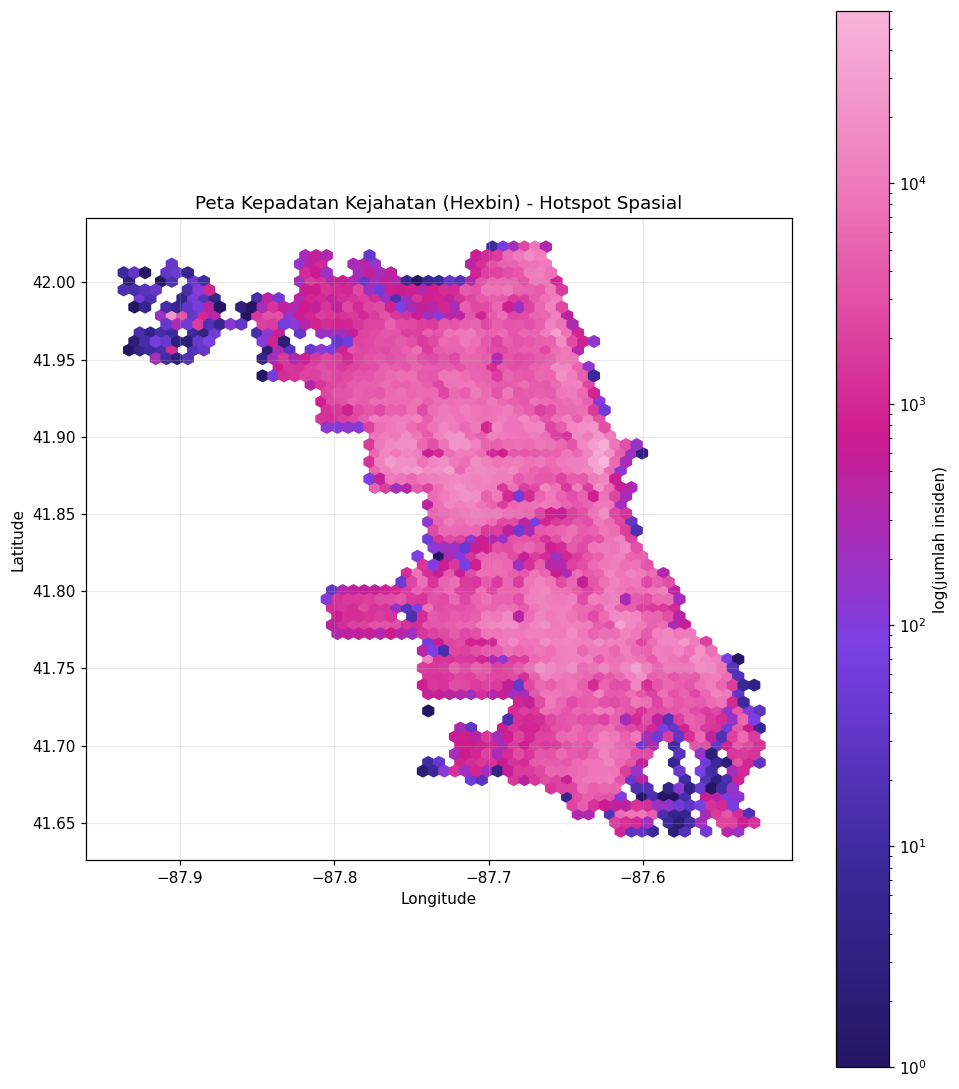

In [22]:
# Hotspot: 2D density (hexbin)
plt.figure(figsize=(9,10))
hb = plt.hexbin(geo['Longitude'], geo['Latitude'], gridsize=60, cmap=PALETTE, mincnt=1, bins='log')
plt.colorbar(hb, label='log(jumlah insiden)')
plt.title('Peta Kepadatan Kejahatan (Hexbin) - Hotspot Spasial')
plt.xlabel('Longitude'); plt.ylabel('Latitude'); plt.gca().set_aspect('equal')
plt.tight_layout(); plt.show()


**Interpretasi - hotspot spasial.** Densitas 2D (hexbin) memperlihatkan risiko sangat tidak merata: terkonsentrasi di area pusat/barat/selatan kota, bukan tersebar seragam. Pola terkelompok ini adalah dasar untuk *spatial decay* - risiko sebuah sel wajar dipengaruhi sel tetangganya, bukan hanya titik itu sendiri.


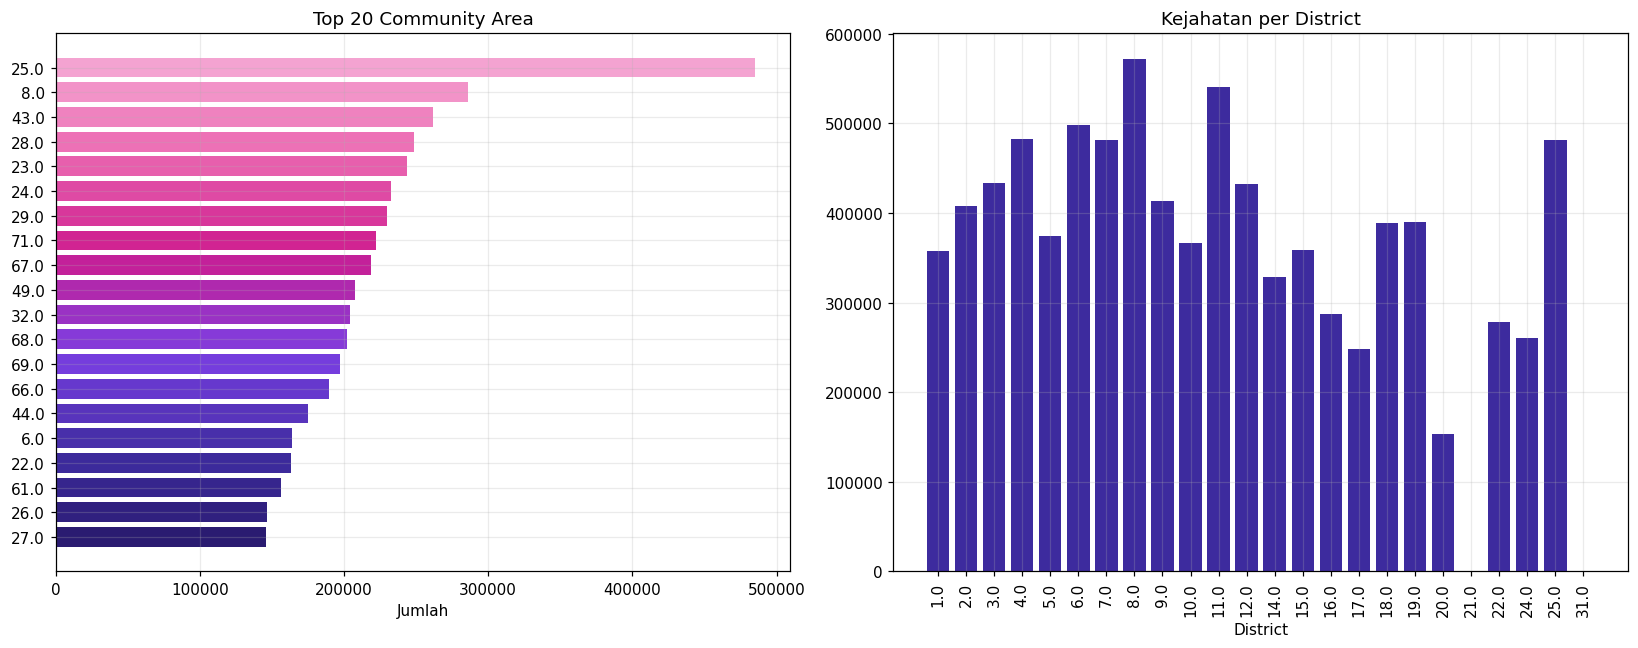

In [23]:
# Kejahatan per Community Area & District
fig, ax = plt.subplots(1,2, figsize=(15,6))
top_ca = d['Community Area'].value_counts().head(20).iloc[::-1]
ax[0].barh(top_ca.index.astype(str), top_ca.values, color=sns.color_palette(PALETTE, len(top_ca)))
ax[0].set_title('Top 20 Community Area'); ax[0].set_xlabel('Jumlah')

by_dist = d['District'].value_counts().sort_index()
ax[1].bar(by_dist.index.astype(str), by_dist.values, color=ACCENT2)
ax[1].set_title('Kejahatan per District'); ax[1].set_xlabel('District')
ax[1].tick_params(axis='x', rotation=90)
plt.tight_layout(); plt.show()


Jumlah sel grid terisi (GRID=0.01 derajat ~1.1km): 746
count       746.000000
mean      11311.163539
std       12232.342564
min           1.000000
25%        1670.000000
50%        7940.500000
75%       16752.750000
max      107964.000000
Name: n, dtype: float64


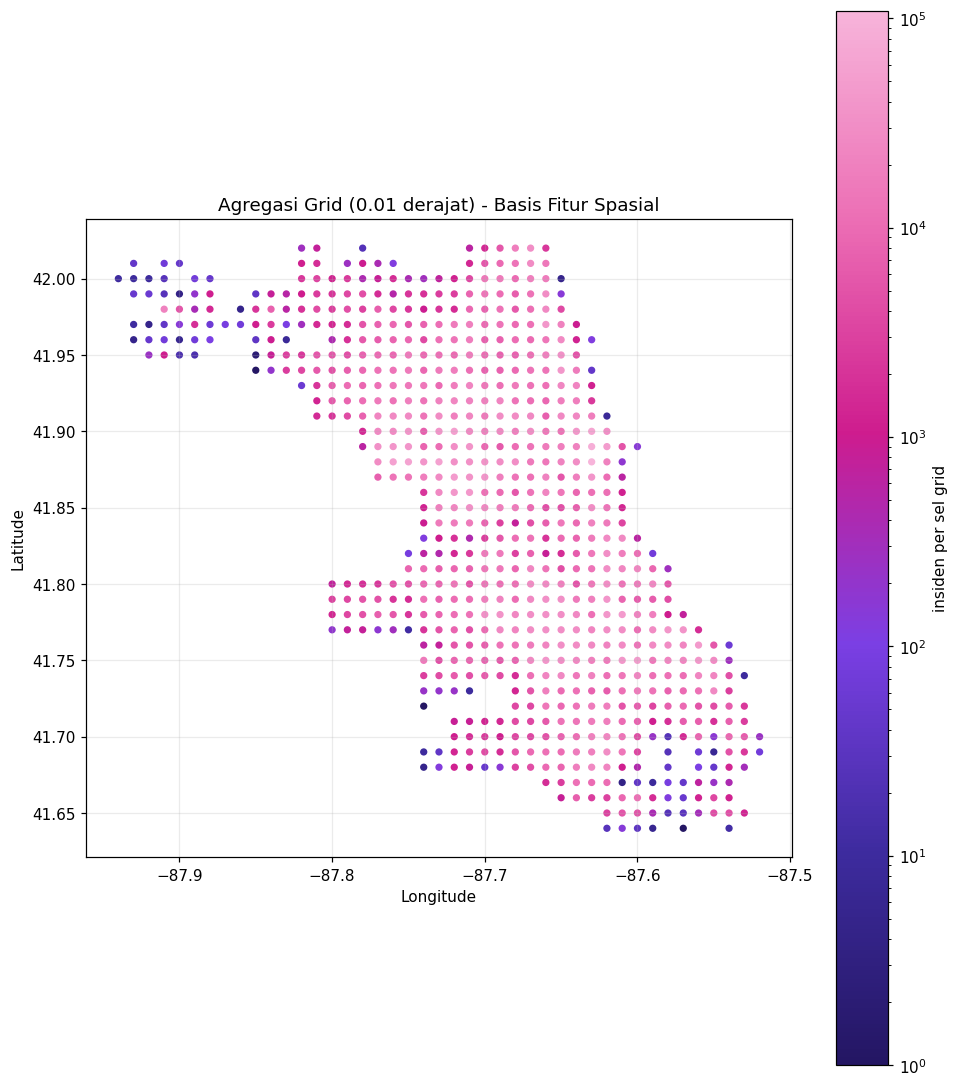

Justifikasi FE: agregasi koordinat kontinu ke grid membuat lokasi berdekatan bisa dibandingkan & dihitung densitasnya.


In [24]:
# Demo grid aggregation: bin koordinat ke grid
GRID = 0.01  # ~1.1 km per sel
geo2 = geo.copy()
geo2['grid_lat'] = (geo2['Latitude']/GRID).round()*GRID
geo2['grid_lon'] = (geo2['Longitude']/GRID).round()*GRID
grid_counts = geo2.groupby(['grid_lat','grid_lon']).size().reset_index(name='n')
print(f'Jumlah sel grid terisi (GRID={GRID} derajat ~1.1km): {len(grid_counts):,}')
print(grid_counts['n'].describe())

plt.figure(figsize=(9,10))
sc = plt.scatter(grid_counts['grid_lon'], grid_counts['grid_lat'], c=grid_counts['n'],
                 cmap=PALETTE, s=14, norm=plt.matplotlib.colors.LogNorm())
plt.colorbar(sc, label='insiden per sel grid')
plt.title(f'Agregasi Grid ({GRID} derajat) - Basis Fitur Spasial')
plt.xlabel('Longitude'); plt.ylabel('Latitude'); plt.gca().set_aspect('equal')
plt.tight_layout(); plt.show()
print('Justifikasi FE: agregasi koordinat kontinu ke grid membuat lokasi berdekatan bisa dibandingkan & dihitung densitasnya.')


**Interpretasi - dasar agregasi grid.** Dengan grid 0,01 derajat (~1,1 km) hanya 746 sel terisi, namun densitasnya timpang ekstrem (median ~7.940 vs maks ~107.964 insiden per sel). Membin koordinat kontinu ke grid membuat lokasi berdekatan bisa dibandingkan, dihitung densitasnya, dan diagregasi per bulan - fondasi unit analisis (sel x bulan) di tahap berikutnya.


## 6. Analisis Severity

Menyediakan sinyal objektif (volume, arrest rate, sifat domestic) untuk menjustifikasi tabel severity pada Pseudo-Labeling.


In [25]:
# Arrest & Domestic rate per Primary Type (Top 20 by volume)
top20 = df['Primary Type'].value_counts().head(20).index
stats = (df[df['Primary Type'].isin(top20)]
         .groupby('Primary Type')
         .agg(volume=('ID','size'),
              arrest_rate=('Arrest','mean'),
              domestic_rate=('Domestic','mean'))
         .sort_values('volume', ascending=False))
stats['arrest_rate'] = (stats['arrest_rate']*100).round(1)
stats['domestic_rate'] = (stats['domestic_rate']*100).round(1)
display(stats)


,volume,arrest_rate,domestic_rate
Primary Type,,,
THEFT,1812951,10.8,3.6
BATTERY,1554443,21.6,53.0
CRIMINAL DAMAGE,970114,6.5,11.5
NARCOTICS,766981,99.3,0.1
ASSAULT,573910,20.1,29.3
OTHER OFFENSE,533160,17.7,37.1
BURGLARY,451173,5.7,1.3
MOTOR VEHICLE THEFT,439408,7.5,0.9
DECEPTIVE PRACTICE,395718,12.1,1.6


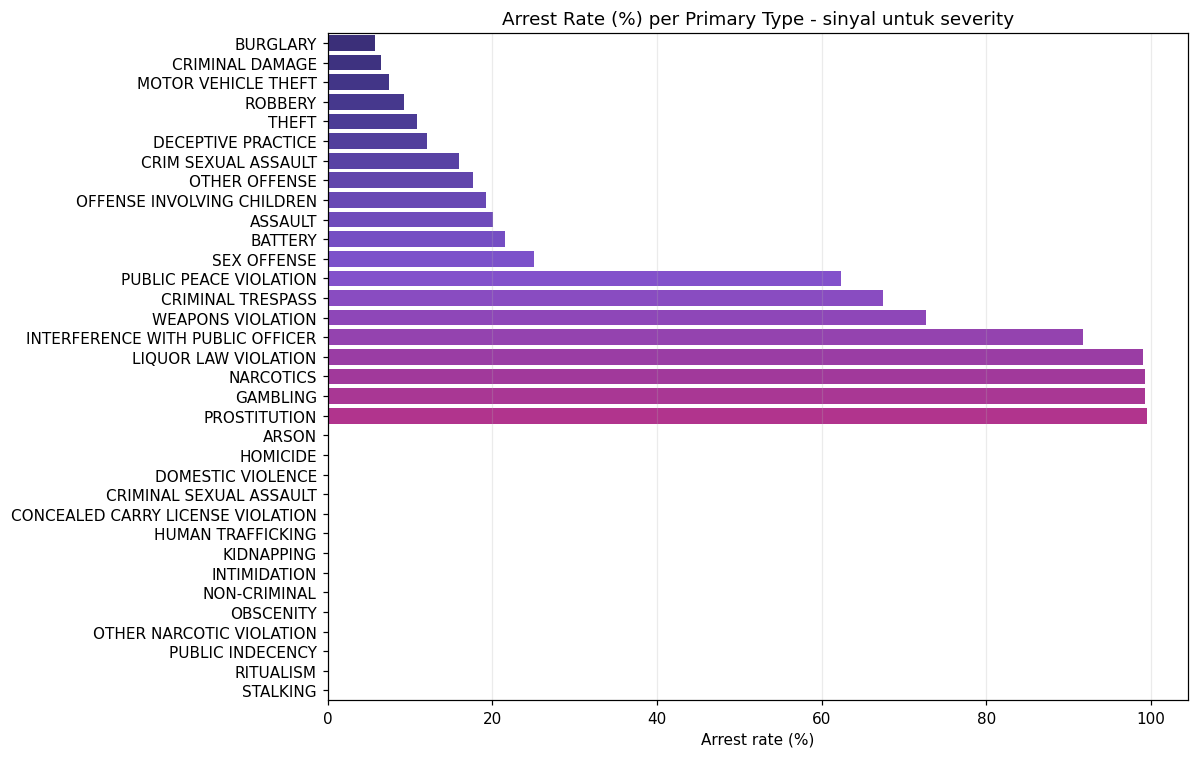

In [26]:
# Visual arrest rate per tipe (proxy severity/enforcement)
s = stats.sort_values('arrest_rate')
plt.figure(figsize=(11,7))
sns.barplot(x=s['arrest_rate'], y=s.index.astype(str),
            hue=s.index.astype(str), palette=brand_palette(len(s)), legend=False)
plt.title('Arrest Rate (%) per Primary Type - sinyal untuk severity')
plt.xlabel('Arrest rate (%)'); plt.ylabel('')
plt.tight_layout(); plt.show()


**Interpretasi - arrest rate bukan severity.** `NARCOTICS` memiliki arrest rate hampir 99% dan `CRIMINAL TRESPASS` ~67%, jauh di atas kejahatan kekerasan berat. Ini karena arrest rate mencerminkan *cara penegakan* (kejahatan yang tertangkap saat terjadi), bukan tingkat bahaya. Pelajaran penting: severity harus diturunkan dari sifat bahaya tipe + deskripsi, bukan dari arrest rate.


In [27]:
# Kombinasi Primary Type + Description paling sering (target severity table)
combo = (df.groupby(['Primary Type','Description']).size()
           .sort_values(ascending=False).head(25).reset_index(name='volume'))
display(combo)
print(f'Total kombinasi unik (Primary Type x Description): '
      f"{df.groupby(['Primary Type','Description']).ngroups:,}")


,Primary Type,Description,volume
0,THEFT,$500 AND UNDER,683281
1,BATTERY,DOMESTIC BATTERY SIMPLE,666895
2,BATTERY,SIMPLE,608023
3,THEFT,OVER $500,465113
4,CRIMINAL DAMAGE,TO VEHICLE,463325
5,CRIMINAL DAMAGE,TO PROPERTY,444434
6,ASSAULT,SIMPLE,391264
7,MOTOR VEHICLE THEFT,AUTOMOBILE,343956
8,BURGLARY,FORCIBLE ENTRY,295572
9,NARCOTICS,POSS: CANNABIS 30GMS OR LESS,278136


Total kombinasi unik (Primary Type x Description): 613


## 7. Analisis Ruang-Waktu

Memberi dasar empiris untuk menentukan seberapa cepat relevansi kejahatan meluruh terhadap waktu (recency) dan jarak (proximity) pada Space-Time Decay.


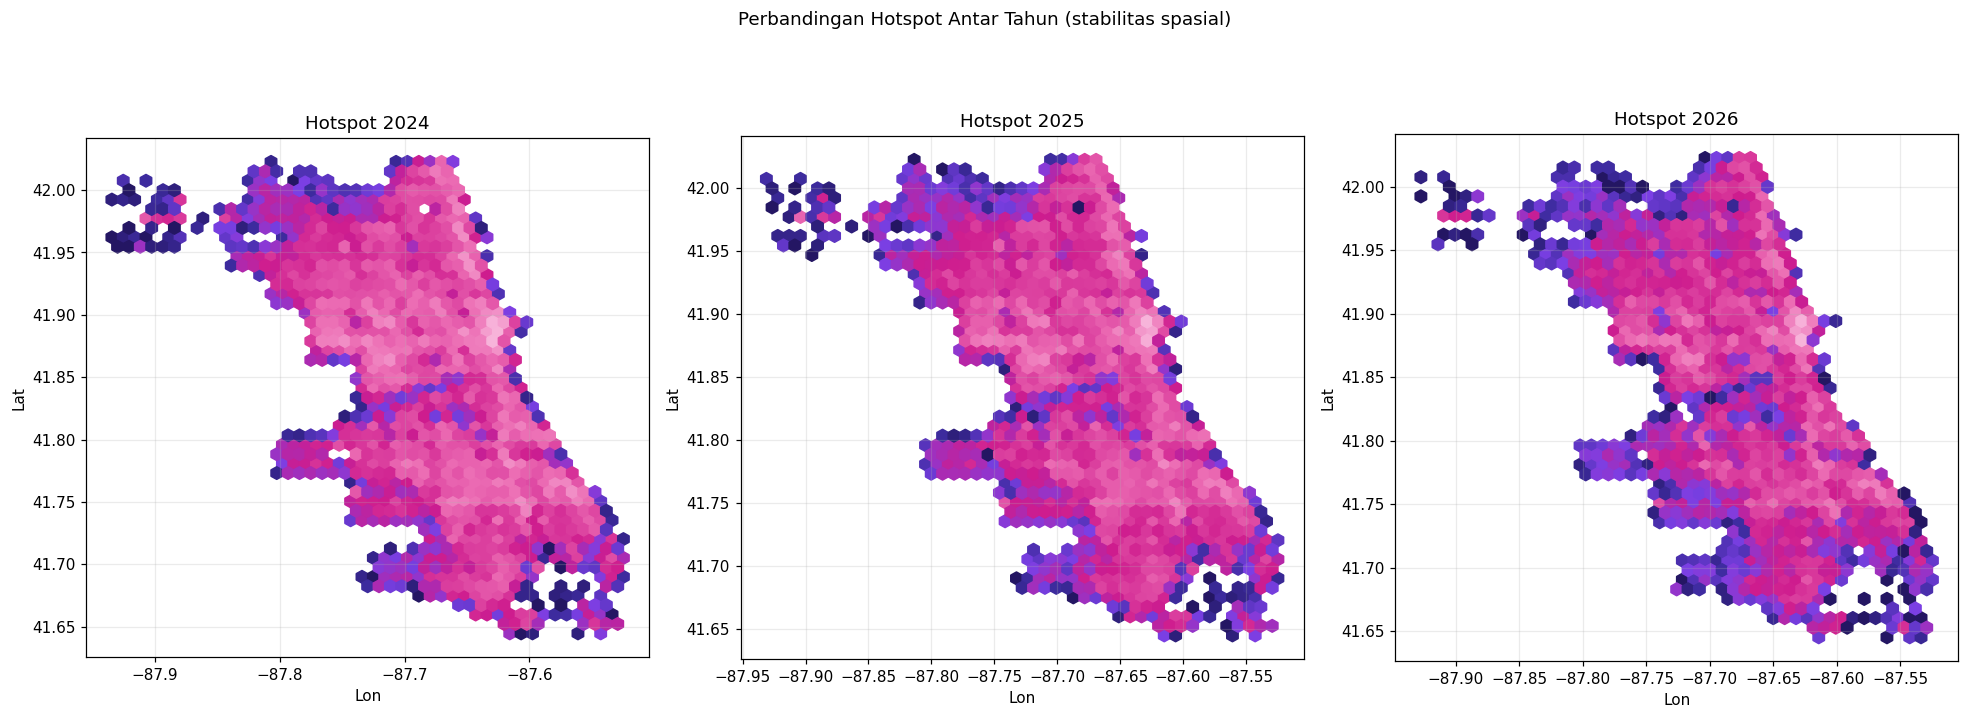

Jika hotspot relatif stabil, decay temporal bisa lebih lambat; jika berubah cepat, decay lebih agresif.


In [28]:
# Stabilitas hotspot antar tahun (dasar temporal decay)
recent_years = sorted(d['year'].dropna().unique())[-3:]
fig, axes = plt.subplots(1, len(recent_years), figsize=(6*len(recent_years),7), squeeze=False)
for ax, yr in zip(axes[0], recent_years):
    sub = geo[geo['Date'].dt.year == yr]
    ax.hexbin(sub['Longitude'], sub['Latitude'], gridsize=45, cmap=PALETTE, mincnt=1, bins='log')
    ax.set_title(f'Hotspot {int(yr)}'); ax.set_aspect('equal')
    ax.set_xlabel('Lon'); ax.set_ylabel('Lat')
plt.suptitle('Perbandingan Hotspot Antar Tahun (stabilitas spasial)')
plt.tight_layout(); plt.show()
print('Jika hotspot relatif stabil, decay temporal bisa lebih lambat; jika berubah cepat, decay lebih agresif.')


**Interpretasi - stabilitas hotspot.** Peringkat area berisiko relatif konsisten antar tahun meski volume total menurun - hotspot tidak berpindah drastis. Karena struktur spasial cukup stabil, *temporal decay* yang dipilih tidak perlu terlalu agresif; half-life beberapa bulan sudah memadai untuk menyeimbangkan recency dan stabilitas.


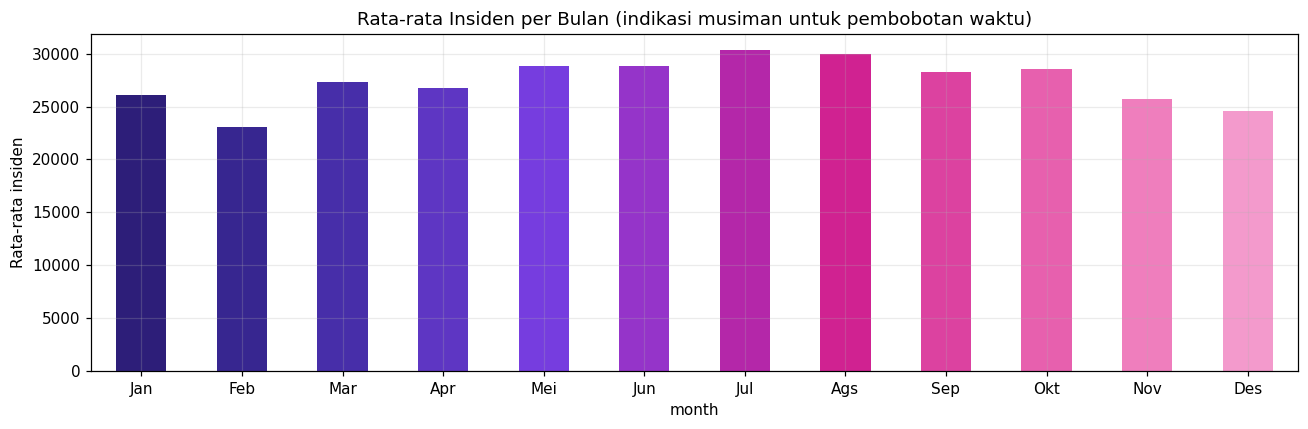

In [29]:
# Rata-rata insiden per bulan kalender (musiman)
monthly_avg = d.groupby('month').size() / d['year'].nunique()
plt.figure(figsize=(12,4))
monthly_avg.plot(kind='bar', color=sns.color_palette(PALETTE,12))
plt.xticks(range(12), month_names, rotation=0)
plt.title('Rata-rata Insiden per Bulan (indikasi musiman untuk pembobotan waktu)')
plt.ylabel('Rata-rata insiden')
plt.tight_layout(); plt.show()


**Interpretasi - musiman.** Rata-rata insiden per bulan kalender memuncak pada bulan-bulan musim panas (sekitar Juli-Agustus) dan menurun di musim dingin. Pola musiman ini menjadi alasan tambahan untuk encoding bulan siklikal dan fitur rolling, agar estimasi risiko tidak bias terhadap bulan pengukuran.


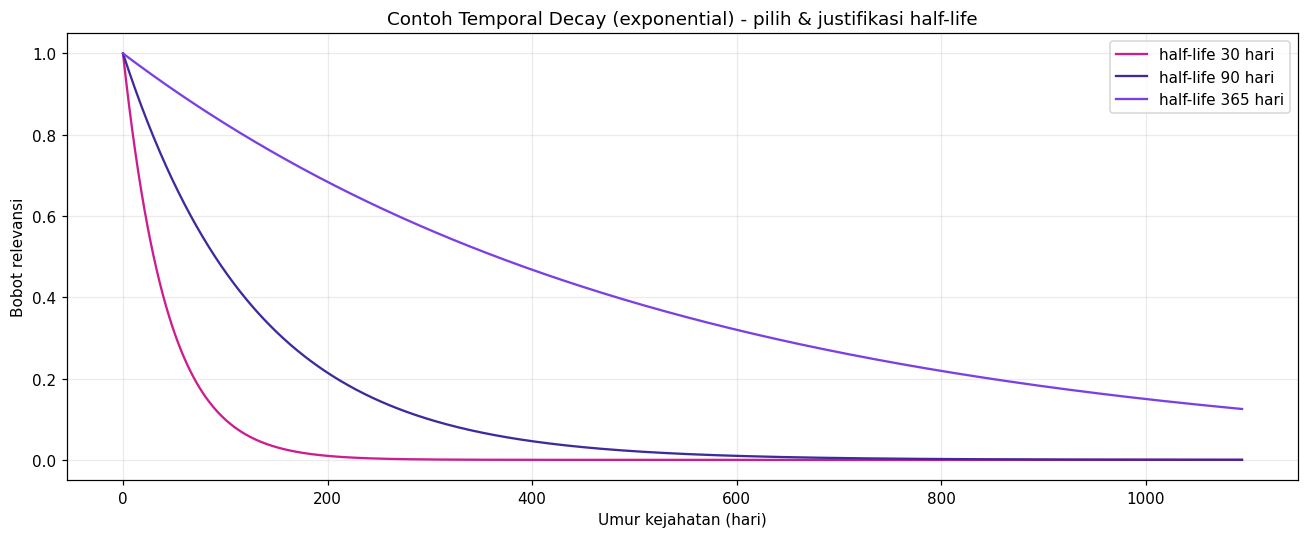

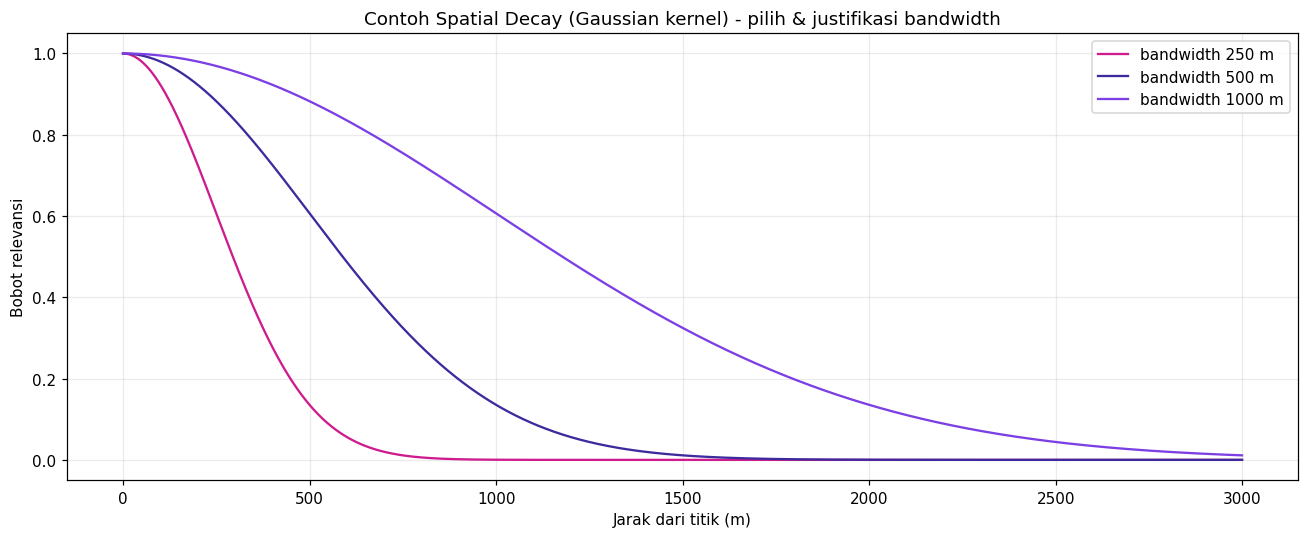

Kombinasi keduanya = Space-Time Decay: bobot = severity x temporal_decay x spatial_decay.


In [30]:
# Ilustrasi fungsi decay untuk pseudo-labeling
days = np.arange(0, 365*3)
for half_life in [30, 90, 365]:
    lam = math.log(2)/half_life
    plt.plot(days, np.exp(-lam*days), label=f'half-life {half_life} hari')
plt.title('Contoh Temporal Decay (exponential) - pilih & justifikasi half-life')
plt.xlabel('Umur kejahatan (hari)'); plt.ylabel('Bobot relevansi')
plt.legend(); plt.tight_layout(); plt.show()

dist = np.arange(0, 3000)
for bw in [250, 500, 1000]:
    plt.plot(dist, np.exp(-(dist**2)/(2*bw**2)), label=f'bandwidth {bw} m')
plt.title('Contoh Spatial Decay (Gaussian kernel) - pilih & justifikasi bandwidth')
plt.xlabel('Jarak dari titik (m)'); plt.ylabel('Bobot relevansi')
plt.legend(); plt.tight_layout(); plt.show()
print('Kombinasi keduanya = Space-Time Decay: bobot = severity x temporal_decay x spatial_decay.')


**Interpretasi - menuju pseudo-labeling.** Ilustrasi fungsi decay menyatukan tiga komponen desain: bobot akhir = `severity x temporal_decay x spatial_decay`. Inilah kerangka yang akan diimplementasikan pada notebook pseudo-labeling untuk membentuk Risk Score 0-100 - severity dari kombinasi Primary Type + Description, temporal decay untuk recency, dan spatial decay untuk pengaruh antar sel tetangga.


## 8. Ringkasan & Rekomendasi

Temuan dan rekomendasi untuk Feature Engineering dan Pseudo-Labeling.

- Temporal: cyclical (sin/cos) encoding untuk hour, dayofweek, month, dayofyear; tambah flag is_weekend, is_night.
- Spatial: grid aggregation (mis. ~0.01 derajat) atau geohash + fitur densitas per sel; BallTree (haversine) untuk tetangga terdekat.
- Severity: skor per Primary Type x Description, dijustifikasi dengan arrest rate, sifat kekerasan, dan volume.
- Space-Time Decay: bobot = severity x exp(-lambda*dt) x exp(-d^2/2*sigma^2), agregasi per (grid x window waktu), normalisasi ke 0-100.


In [31]:
# Ringkasan 
summary = {
    'Total insiden': f'{len(df):,}',
    'Rentang tanggal': f"{df['Date'].min()} - {df['Date'].max()}",
    'Jumlah Primary Type': int(df['Primary Type'].nunique()),
    'Jumlah Community Area': int(df['Community Area'].nunique()),
    'Baris tanpa koordinat (%)': round(df['Latitude'].isna().mean()*100, 2),
    'Arrest rate (%)': round(df['Arrest'].mean()*100, 2),
    'Domestic rate (%)': round(df['Domestic'].mean()*100, 2),
}
for k,v in summary.items():
    print(f'{k:32s}: {v}')


Total insiden                   : 8,534,663
Rentang tanggal                 : 2001-01-01 00:00:00 - 2026-04-11 00:00:00
Jumlah Primary Type             : 34
Jumlah Community Area           : 78
Baris tanpa koordinat (%)       : 1.13
Arrest rate (%)                 : 25.11
Domestic rate (%)               : 17.29
